In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from pycaret.regression import *



#load data set

model = pd.read_csv("dataset_final.csv")

In [4]:
#EDA expolaroty data analysis
model.info() #meliat apakah data ada yang missing atau tidak, melihat barapa jumla data nya dan meliat tipe data nya
model.describe() #melihat statistik data, seperti mean, median, modus, standar deviasi, min, max, dan 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   usia                            2000 non-null   int64  
 1   jenis_kelamin                   2000 non-null   object 
 2   bmi                             2000 non-null   float64
 3   status_merokok                  2000 non-null   object 
 4   tingkat_aktivitas_fisik         2000 non-null   object 
 5   jam_tidur_per_malam             2000 non-null   int64  
 6   tingkat_stres                   2000 non-null   object 
 7   frekuensi_makan_pedas           2000 non-null   object 
 8   frekuensi_makan_berlemak        2000 non-null   object 
 9   konsumsi_kopi_per_hari          2000 non-null   int64  
 10  konsumsi_alkohol                2000 non-null   object 
 11  minuman_bersoda_per_minggu      2000 non-null   int64  
 12  frekuensi_fast_food_per_minggu  20

,usia,bmi,jam_tidur_per_malam,konsumsi_kopi_per_hari,minuman_bersoda_per_minggu,frekuensi_fast_food_per_minggu,risiko_gerd
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.0000
mean,41.675000,26.570050,6.590000,2.474500,7.091000,3.589500,0.5050
std,13.666666,4.889564,1.691251,1.701704,4.357317,2.277407,0.5001
min,18.000000,18.000000,4.000000,0.000000,0.000000,0.000000,0.0000
25%,30.000000,22.300000,5.000000,1.000000,3.000000,2.000000,0.0000
50%,42.000000,26.700000,7.000000,2.000000,7.000000,4.000000,1.0000
75%,53.000000,30.900000,8.000000,4.000000,11.000000,6.000000,1.0000
max,65.000000,35.000000,9.000000,5.000000,14.000000,7.000000,1.0000


In [5]:
model.head() #melihat 5 data teratas
model.shape #melihat jumlah data yang ada pada setiap kolom


(2000, 15)

In [6]:
model.isnull().sum() #melihat apakah ada data yang missing atau tidak, jika ada akan muncul jumlah data yang missing untuk setiap kolomnya

usia                              0
jenis_kelamin                     0
bmi                               0
status_merokok                    0
tingkat_aktivitas_fisik           0
jam_tidur_per_malam               0
tingkat_stres                     0
frekuensi_makan_pedas             0
frekuensi_makan_berlemak          0
konsumsi_kopi_per_hari            0
konsumsi_alkohol                  0
minuman_bersoda_per_minggu        0
frekuensi_fast_food_per_minggu    0
makan_larut_malam                 0
risiko_gerd                       0
dtype: int64

In [7]:

model_final = model.drop(['usia'], axis=1) #menghapus kolom usia karena tidak terlalu berpengaruh terhadap hasil prediksi   
model_final.head() #melihat 5 data teratas setelah kolom usia dihapus

,jenis_kelamin,bmi,status_merokok,tingkat_aktivitas_fisik,jam_tidur_per_malam,tingkat_stres,frekuensi_makan_pedas,frekuensi_makan_berlemak,konsumsi_kopi_per_hari,konsumsi_alkohol,minuman_bersoda_per_minggu,frekuensi_fast_food_per_minggu,makan_larut_malam,risiko_gerd
0,Laki-laki,34.9,Tidak Merokok,Rendah,6,Sedang,Kadang,Kadang,1,Mingguan,5,1,Tidak,0
1,Laki-laki,31.9,Perokok Aktif,Rendah,4,Tinggi,Kadang,Kadang,5,Sesekali,14,5,Ya,1
2,Perempuan,29.8,Perokok Aktif,Tinggi,4,Sedang,Jarang,Sering,1,Mingguan,7,2,Ya,1
3,Perempuan,27.1,Perokok Aktif,Tinggi,4,Tinggi,Jarang,Jarang,2,Tidak Pernah,12,6,Tidak,1
4,Laki-laki,25.6,Tidak Merokok,Sedang,7,Tinggi,Kadang,Sering,0,Tidak Pernah,6,1,Ya,1


In [8]:
model_final['frekuensi_makan_pedas'].count() #melihat jumlah data pada kolom frekuensi_makan_pedas, karena data ini memiliki banyak nilai 0, maka kita akan menghapus kolom ini karena tidak terlalu berpengaruh terhadap hasil prediksi

2000

In [9]:
model_final.describe(include='object') #melihat statistik data untuk data kategorikal, seperti jumlah kategori, frekuensi, dan nilai unik

,jenis_kelamin,status_merokok,tingkat_aktivitas_fisik,tingkat_stres,frekuensi_makan_pedas,frekuensi_makan_berlemak,konsumsi_alkohol,makan_larut_malam
count,2000,2000,2000,2000,2000,2000,2000,2000
unique,2,3,3,3,5,5,4,2
top,Perempuan,Tidak Merokok,Sedang,Sedang,Kadang,Kadang,Tidak Pernah,Tidak
freq,1018,1131,802,822,607,613,846,1154


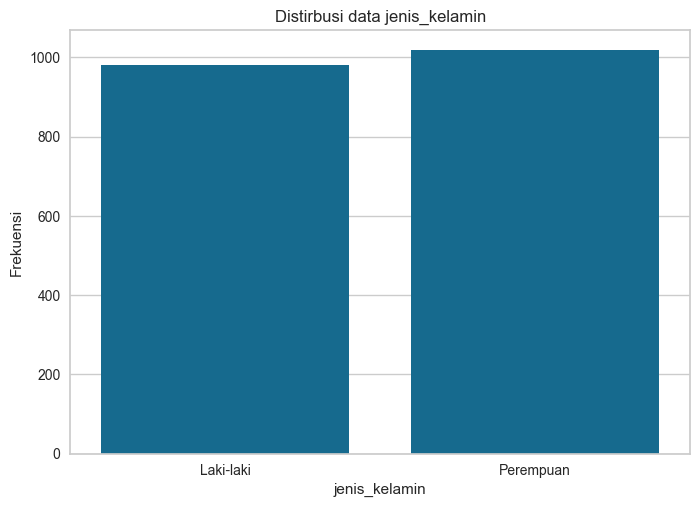

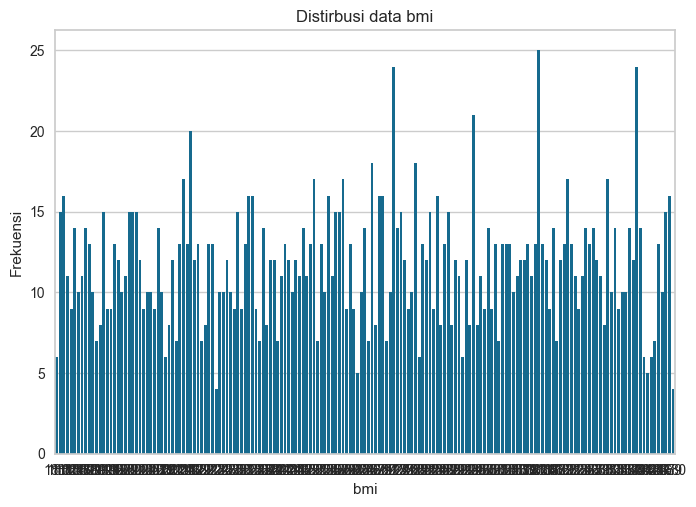

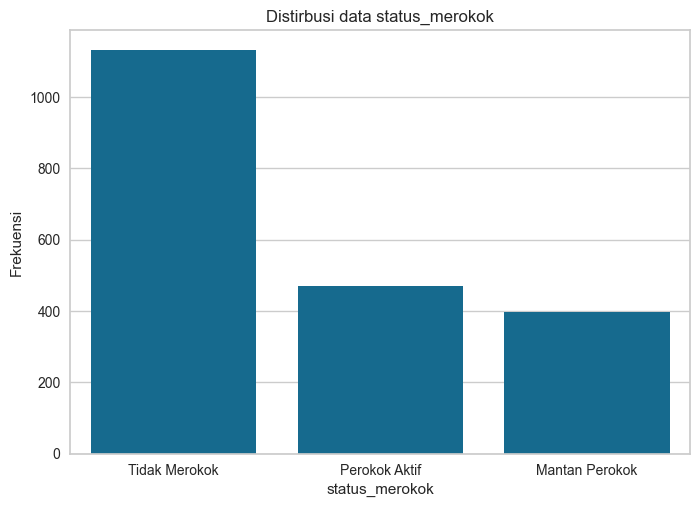

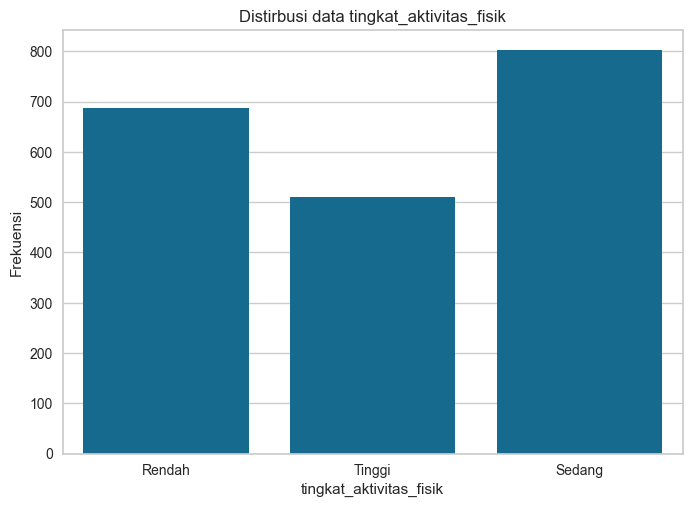

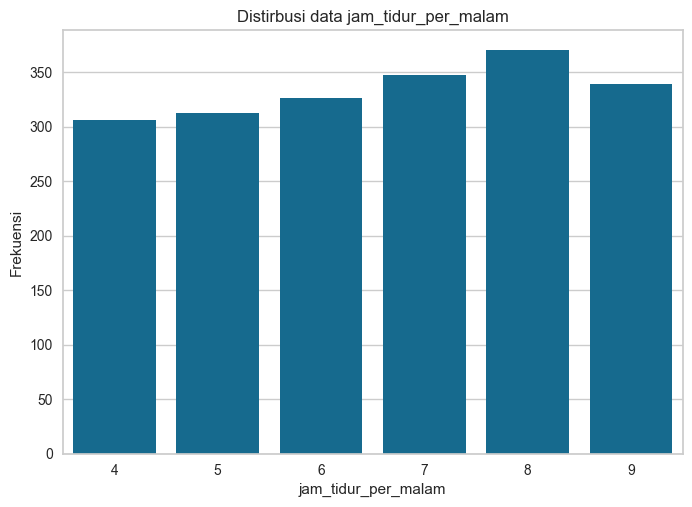

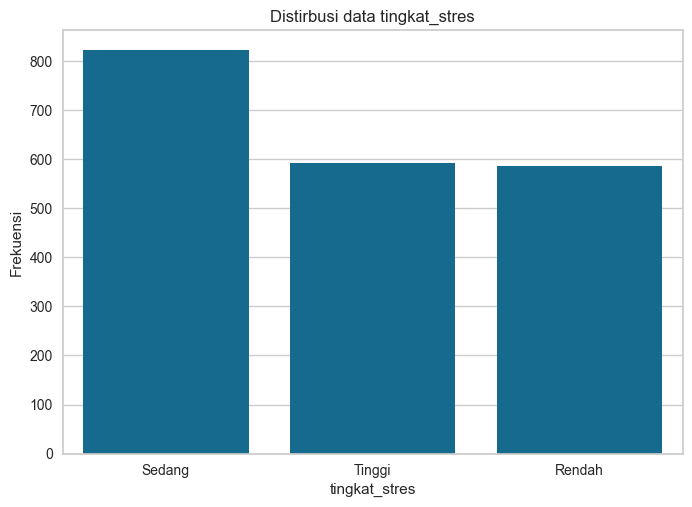

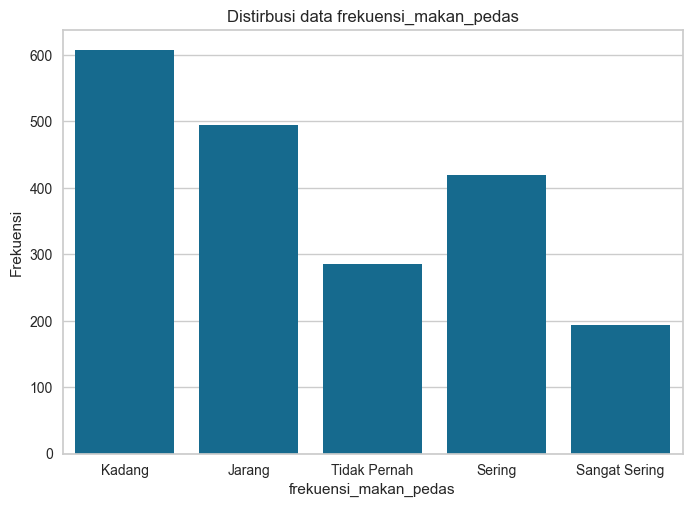

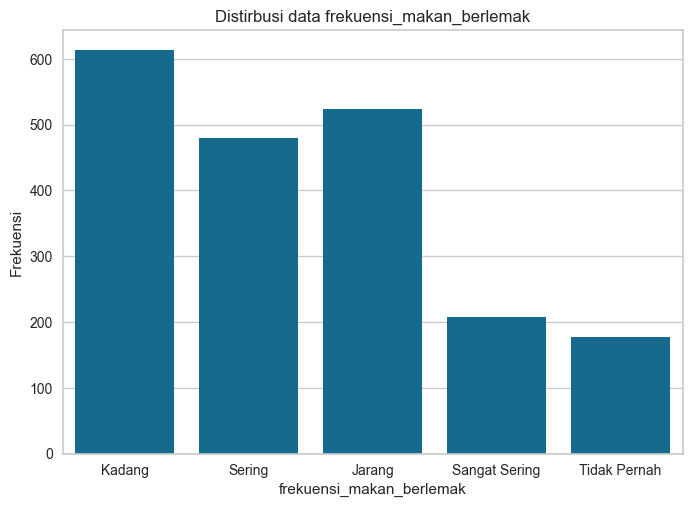

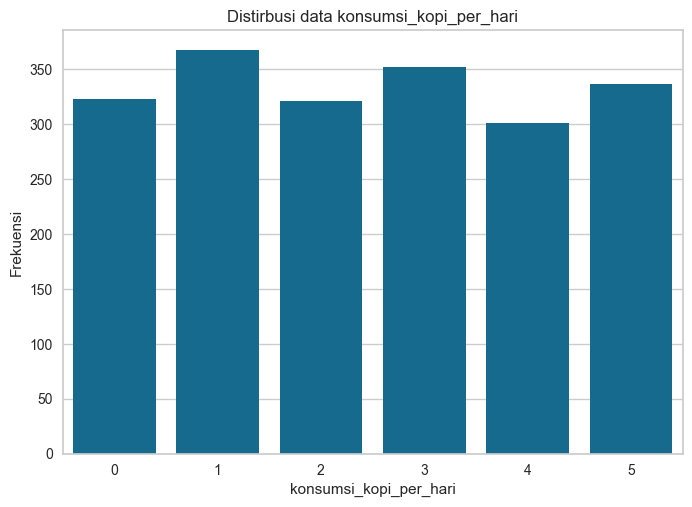

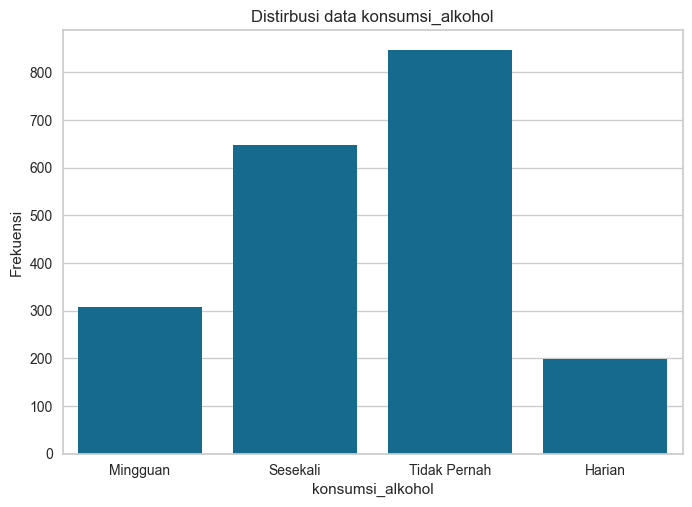

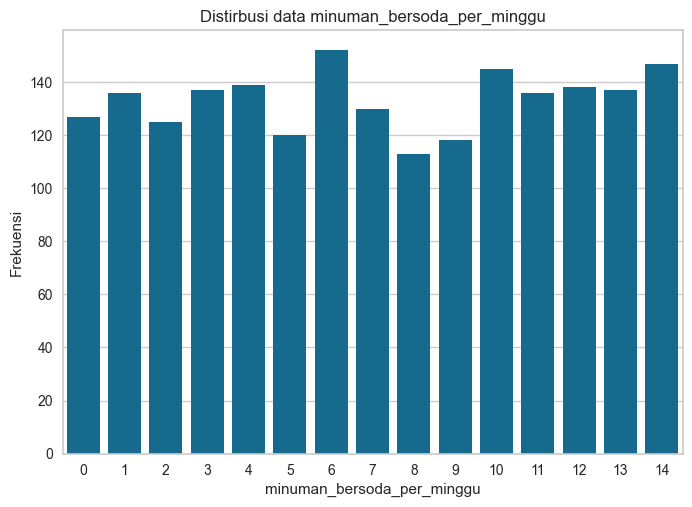

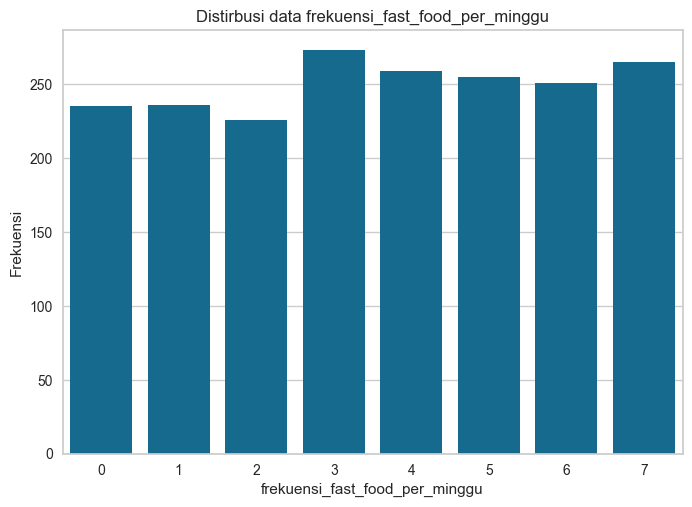

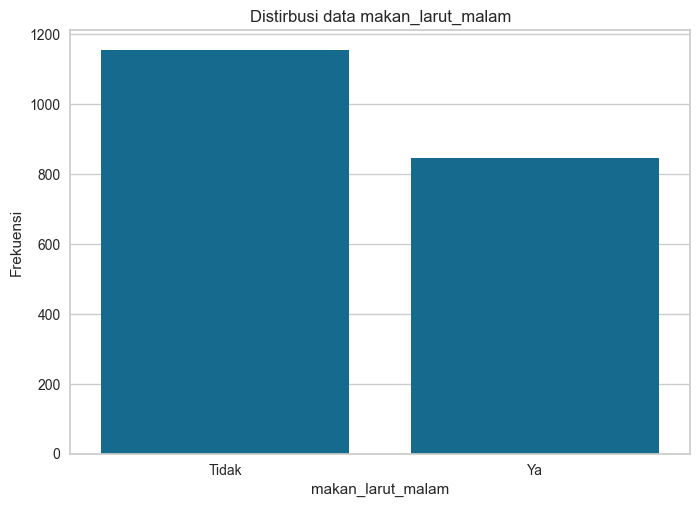

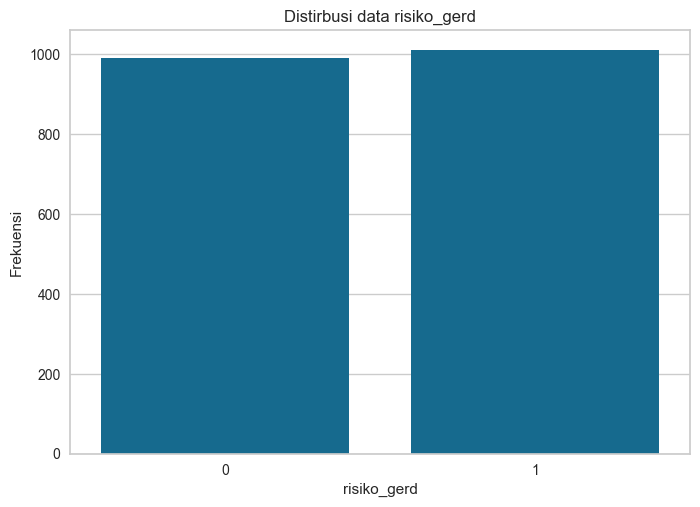

In [10]:
#melihat distibusi data mengunakan hhsitogram

for i in model_final.columns:
    
    plt.Figure(figsize=(50,5))
    sns.countplot(x=model_final[i])
    
    plt.title(f"Distirbusi data {i}")
    plt.xlabel(i)
    plt.ylabel("Frekuensi")
    plt.show() 

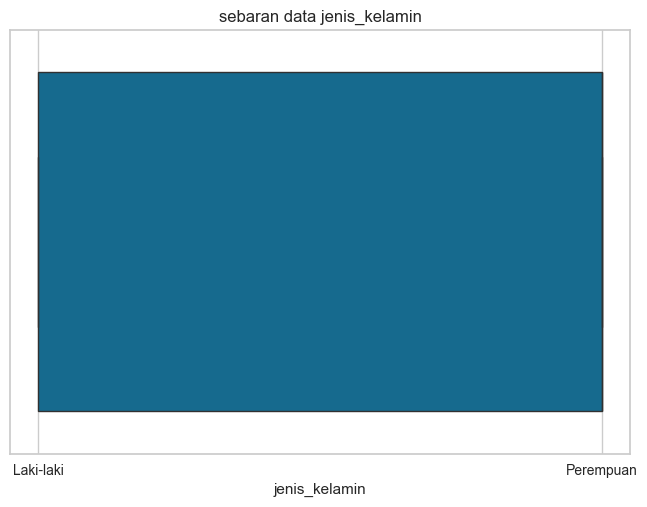

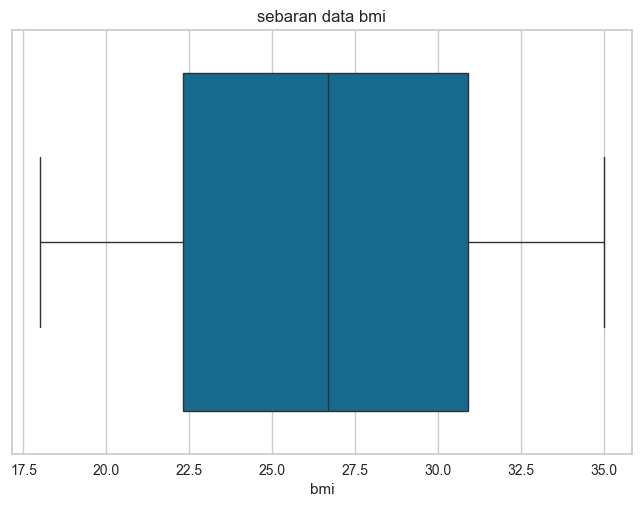

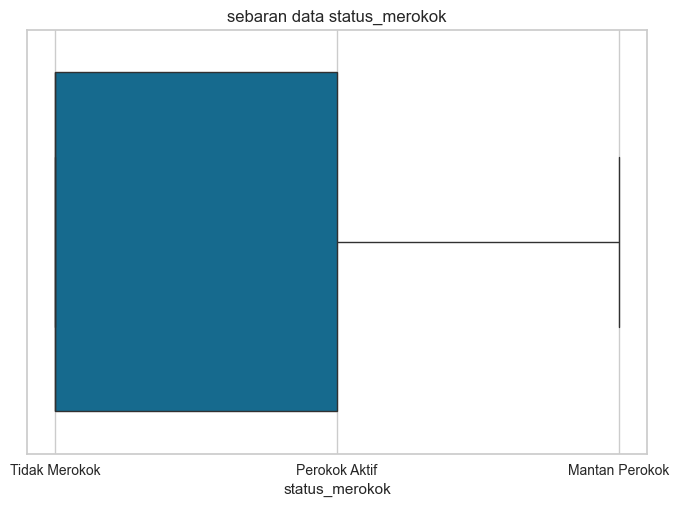

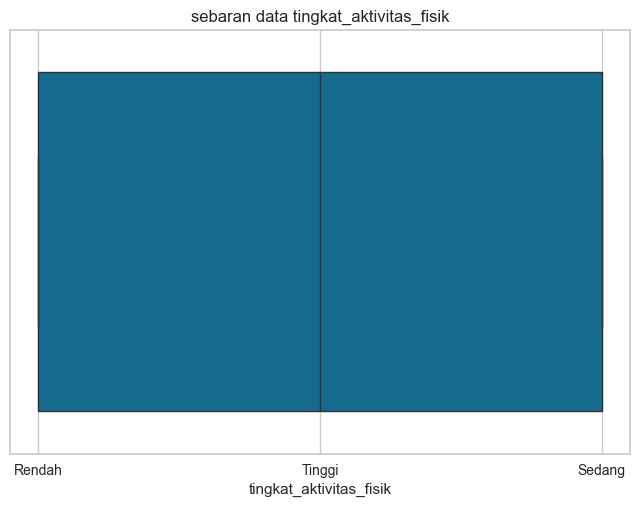

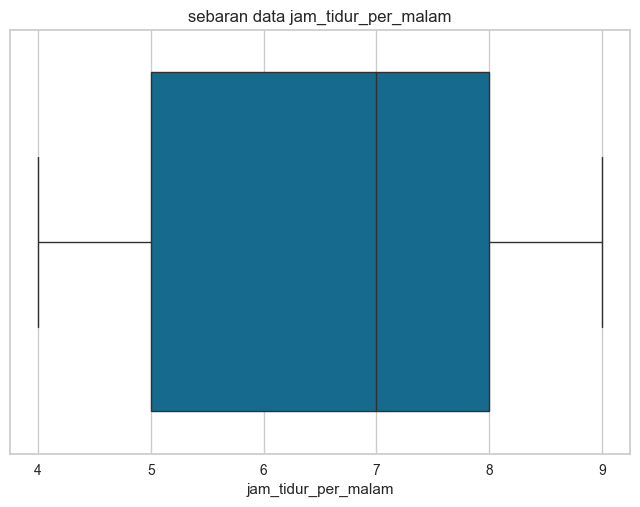

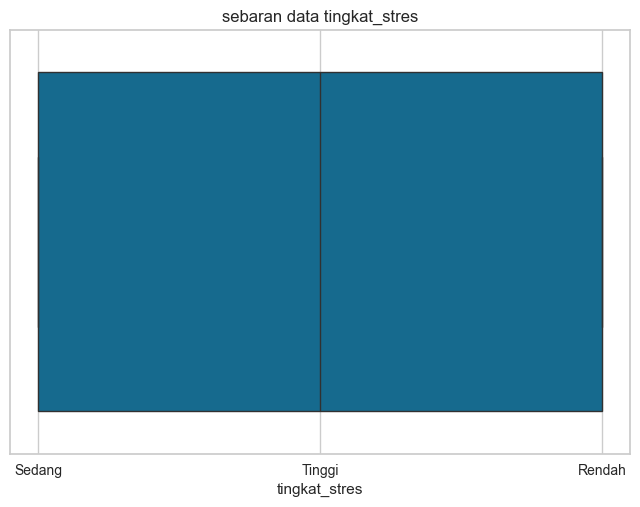

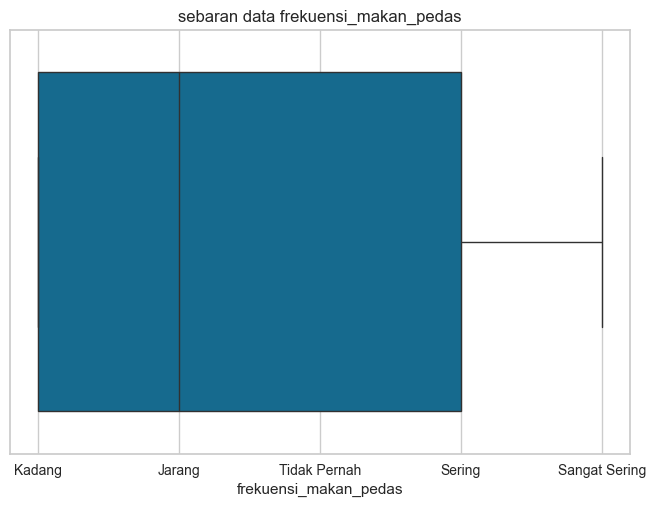

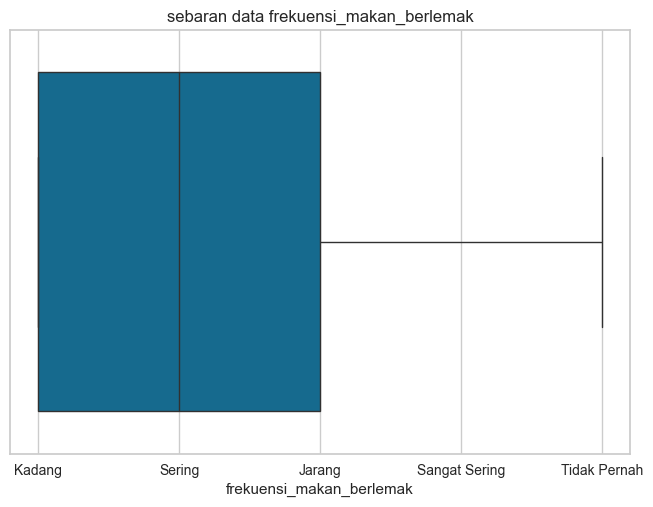

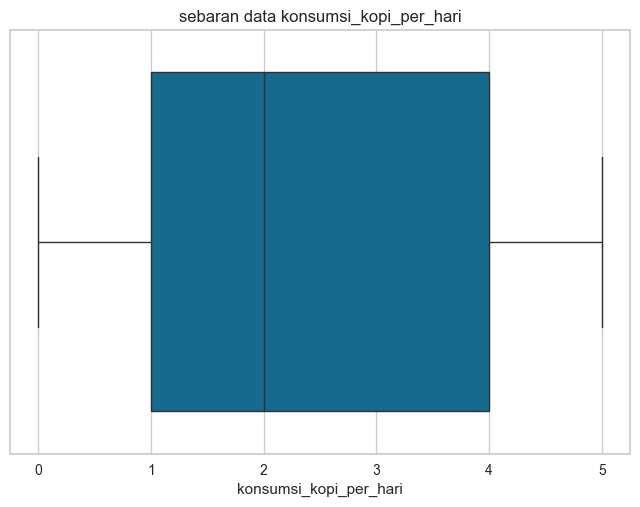

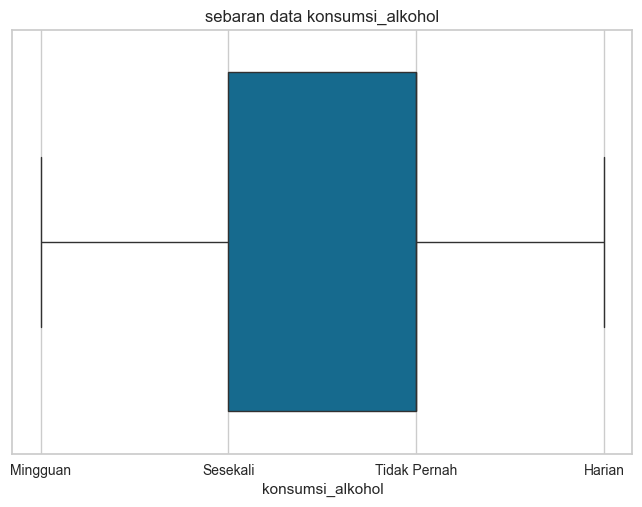

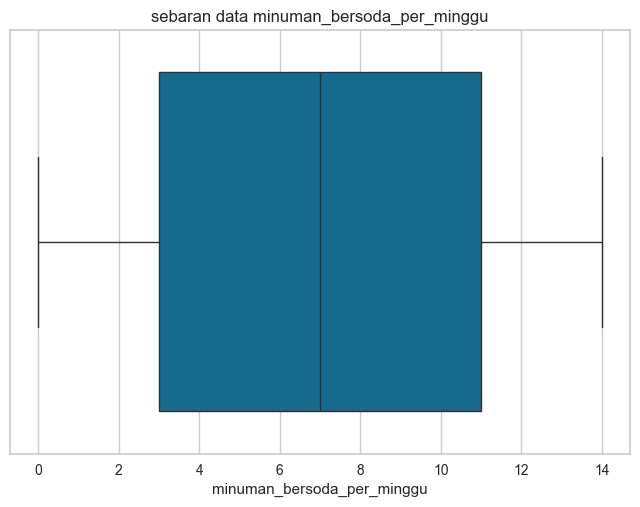

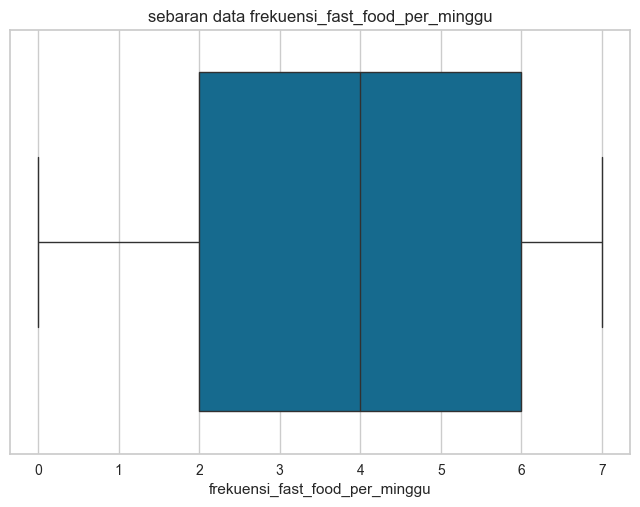

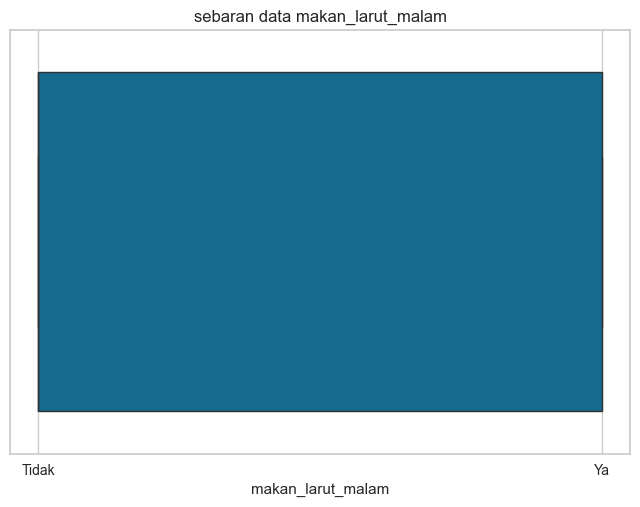

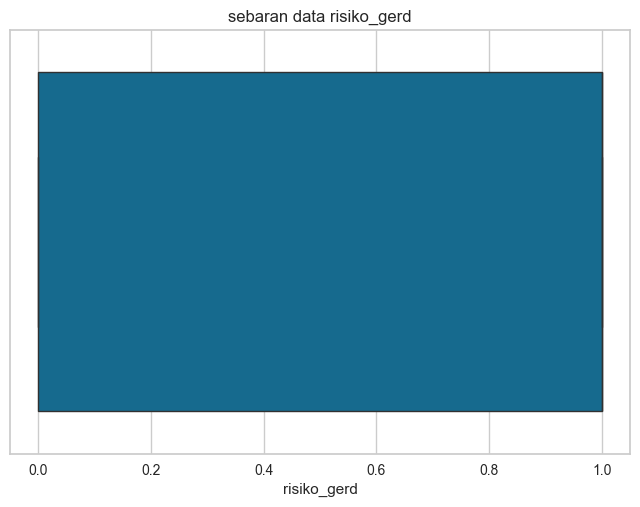

In [27]:
#melihat sebaran data menggunakan boxplot

for i in model_final.columns:
    plt.Figure(figsize=(20,5))
    sns.boxplot(x=model_final[i])
    plt.xlabel(i)
    plt.title(f"sebaran data {i}")
    plt.show()

In [12]:
#melihat data IR ( imabalence rasio) mengunakn if statement


for i in model_final.columns:
    
    jumlan = model_final[i].value_counts() #bagian ini untuk menghitung dsitribusi data disetiap class

    
    max_value = jumlan.max()
    min_value = jumlan.min()
    
    rasio = max_value / min_value
    
    if rasio < 1.5:
        print(f"data tidak imbalence pada kolom {i} dengan rasio{rasio:.2f}")
    elif rasio > 1.5 and rasio <= 3:
        print(f"data sedikit imbalence pada kolom {i} dengan rasio{rasio:.2f}")
    else:
        print(f"data imbalence pada kolom {i} dengan rasio{rasio:.2f}")


data tidak imbalence pada kolom jenis_kelamin dengan rasio1.04
data imbalence pada kolom bmi dengan rasio6.25
data sedikit imbalence pada kolom status_merokok dengan rasio2.84
data sedikit imbalence pada kolom tingkat_aktivitas_fisik dengan rasio1.57
data tidak imbalence pada kolom jam_tidur_per_malam dengan rasio1.21
data tidak imbalence pada kolom tingkat_stres dengan rasio1.40
data imbalence pada kolom frekuensi_makan_pedas dengan rasio3.13
data imbalence pada kolom frekuensi_makan_berlemak dengan rasio3.46
data tidak imbalence pada kolom konsumsi_kopi_per_hari dengan rasio1.22
data imbalence pada kolom konsumsi_alkohol dengan rasio4.25
data tidak imbalence pada kolom minuman_bersoda_per_minggu dengan rasio1.35
data tidak imbalence pada kolom frekuensi_fast_food_per_minggu dengan rasio1.21
data tidak imbalence pada kolom makan_larut_malam dengan rasio1.36
data tidak imbalence pada kolom risiko_gerd dengan rasio1.02


<Axes: xlabel='count', ylabel='frekuensi_makan_berlemak'>

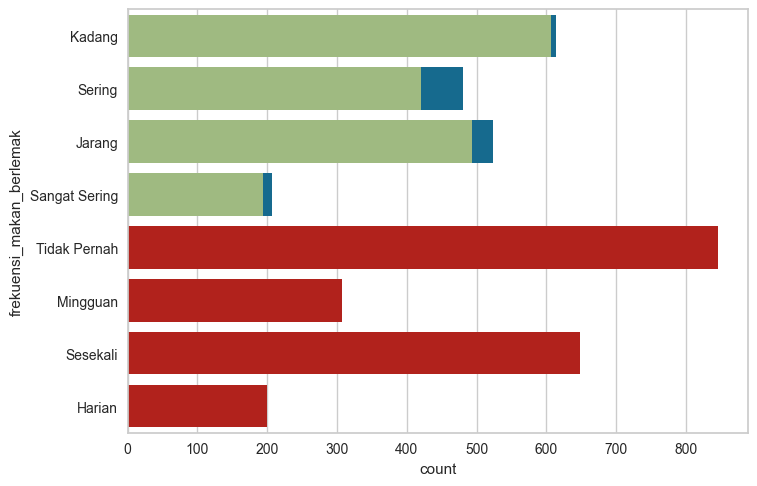

In [13]:
#PENGECEKAN DATA IMBALENCE UNTUK KATEGORIKAL
import seaborn as sns
model_final['frekuensi_makan_berlemak' ].value_counts()
model_final['frekuensi_makan_pedas' ].value_counts()
model_final['konsumsi_alkohol' ].value_counts()

sns.countplot(model_final['frekuensi_makan_berlemak'])
sns.countplot(model_final['frekuensi_makan_pedas'])
sns.countplot(model_final['konsumsi_alkohol']) 



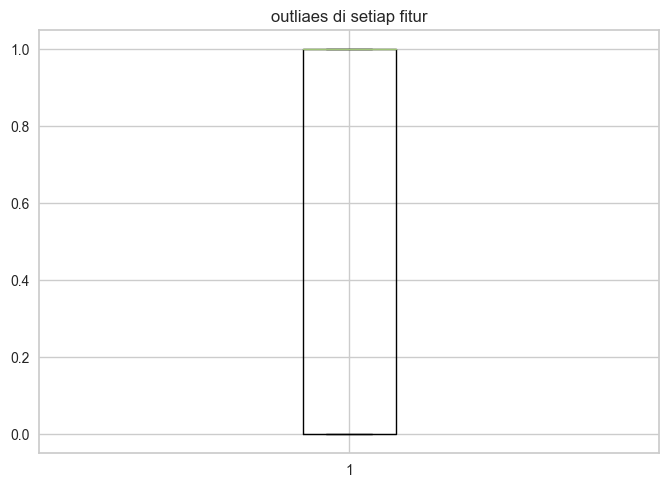

In [14]:
#detector and handling outliers
def outlier(model_final):
    Q1 = int(model_final["risiko_gerd"].quantile(0.25))
    Q3 = int(model_final["risiko_gerd"].quantile(0.75))
         
    IQR = Q3 - Q1
    lower_data = Q1 - 1.5 * IQR
    upper_data = Q3 + 1.5 * IQR
        
    outliers = model_final[(model_final["risiko_gerd"] < lower_data) | (model_final["risiko_gerd"] > upper_data)]
        
    return outliers
plt.boxplot(model_final["risiko_gerd"])
plt.title("outliaes di setiap fitur")
plt.show()

In [15]:
#spliting data

#jika tidak dilakuan spliting data maka akan menyebabkan data leakege / kebocoraan data
x = model_final.drop(columns=['risiko_gerd']) #DISINI KITA MEMISAHKAN ANTARA FITUR DAN TARGET
y = model_final['risiko_gerd'] #INI BAGIAN TARGETNYA

x_latih, x_uji, y_latih, y_uji = train_test_split(x, y , test_size=0.3, random_state=42)
#melihat data apakah sudah terpisah atau belum
print(x.shape)  # kita melihat jumlah row dan colum di data yang sudah dipisah
print(y.shape) # melihat jumlah data yang sudah dipisah

(2000, 13)
(2000,)


In [16]:
x # sebeagia fitur kita 
y # sebgai target kita 

0       0
1       1
2       1
3       1
4       1
       ..
1995    1
1996    0
1997    0
1998    0
1999    1
Name: risiko_gerd, Length: 2000, dtype: int64

In [17]:
#feature encoding
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
x_latih_encode = encoder.fit_transform(x_latih)
x_uji_encode = encoder.transform(x_uji)

encoding_df = pd.DataFrame(x_latih_encode, columns=encoder.get_feature_names_out())
print(encoding_df.head())


   jenis_kelamin_Laki-laki  jenis_kelamin_Perempuan  bmi_18.0  bmi_18.1  \
0                      0.0                      1.0       0.0       0.0   
1                      1.0                      0.0       0.0       0.0   
2                      0.0                      1.0       0.0       0.0   
3                      0.0                      1.0       0.0       0.0   
4                      1.0                      0.0       0.0       0.0   

   bmi_18.2  bmi_18.3  bmi_18.4  bmi_18.5  bmi_18.6  bmi_18.7  ...  \
0       0.0       0.0       0.0       0.0       0.0       0.0  ...   
1       0.0       0.0       0.0       0.0       0.0       0.0  ...   
2       0.0       0.0       0.0       0.0       0.0       0.0  ...   
3       0.0       0.0       0.0       0.0       0.0       0.0  ...   
4       0.0       0.0       0.0       0.0       0.0       0.0  ...   

   frekuensi_fast_food_per_minggu_0  frekuensi_fast_food_per_minggu_1  \
0                               1.0                    

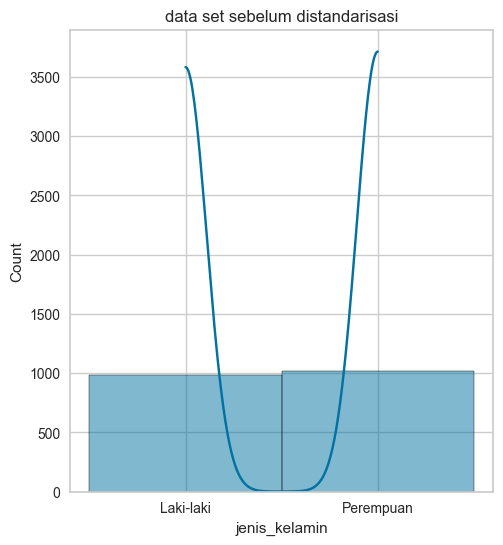

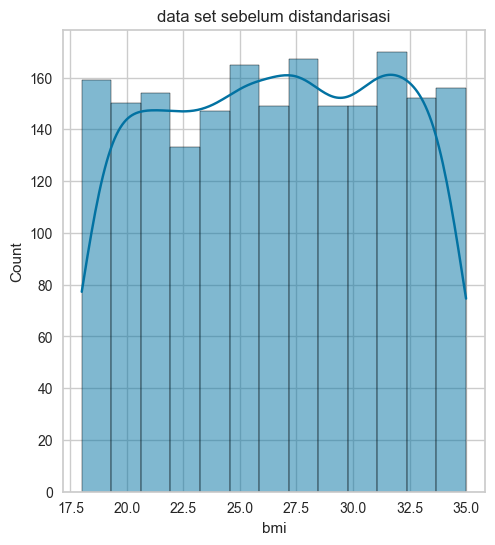

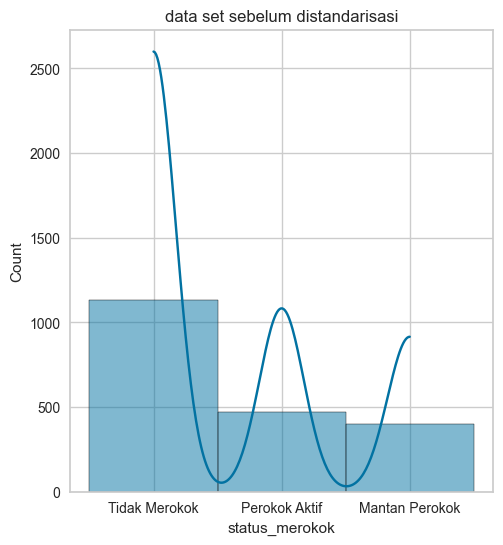

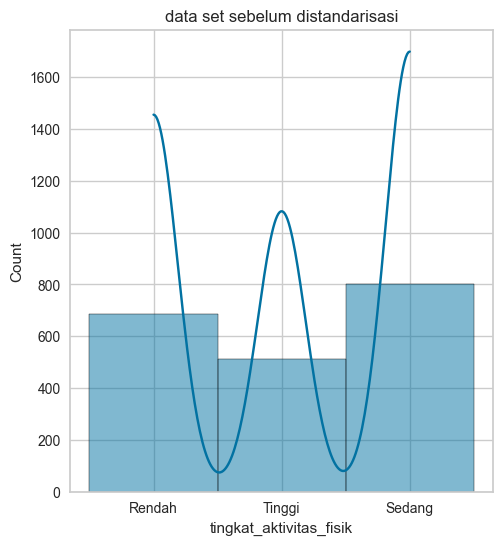

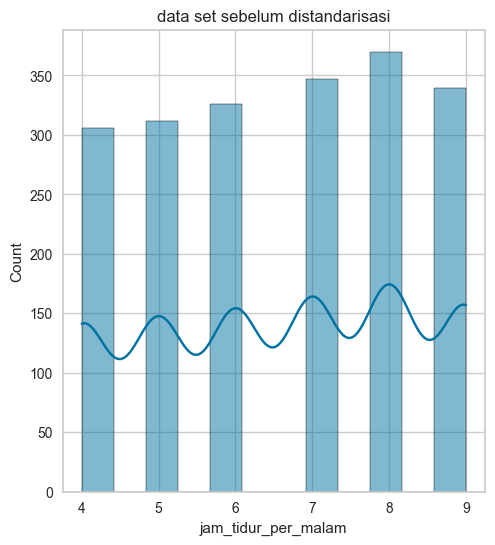

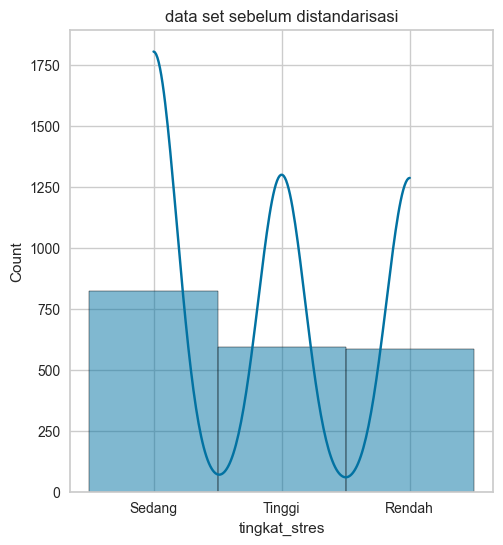

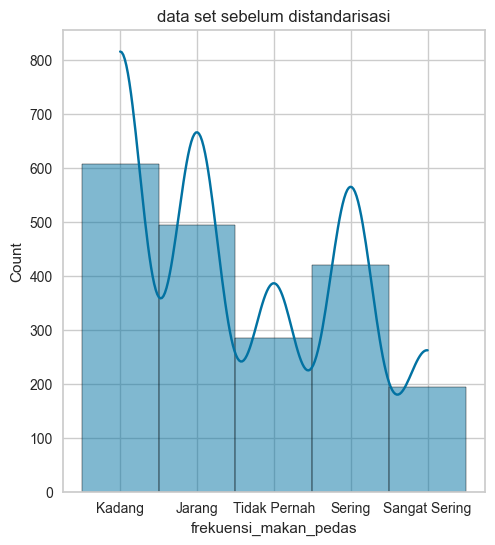

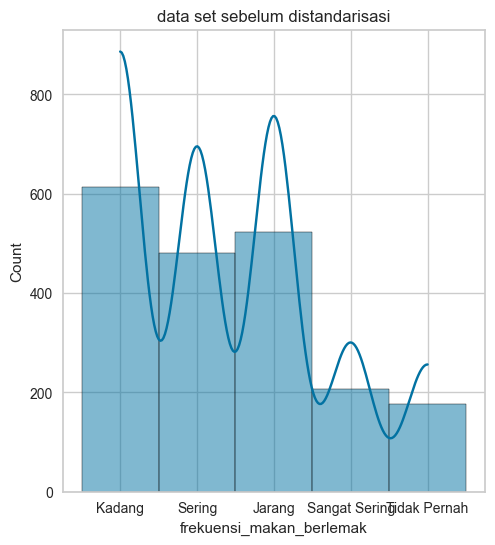

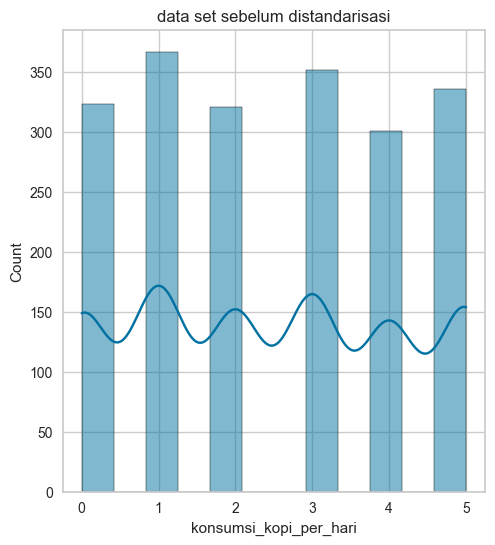

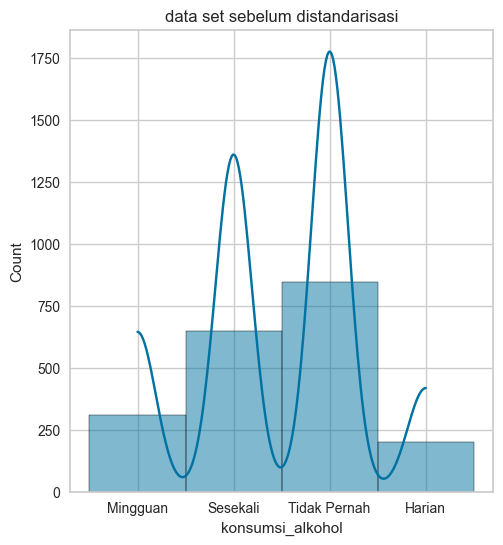

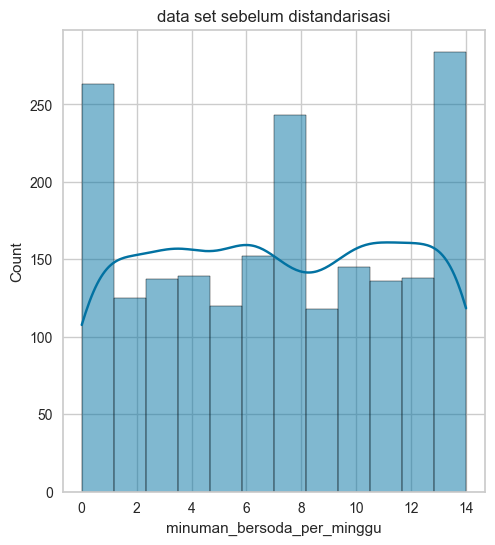

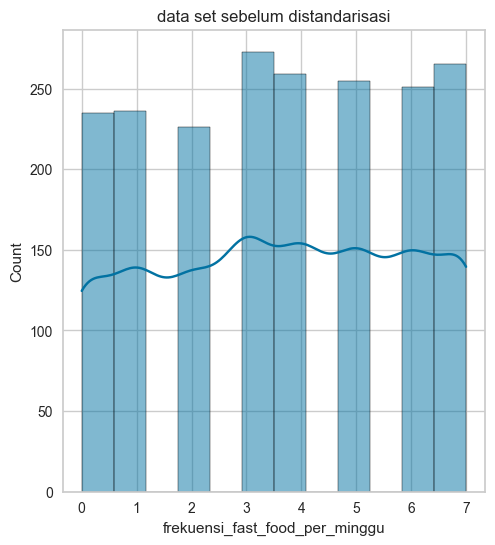

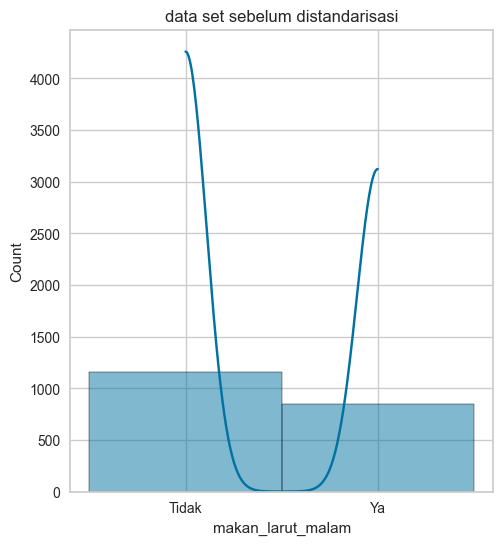

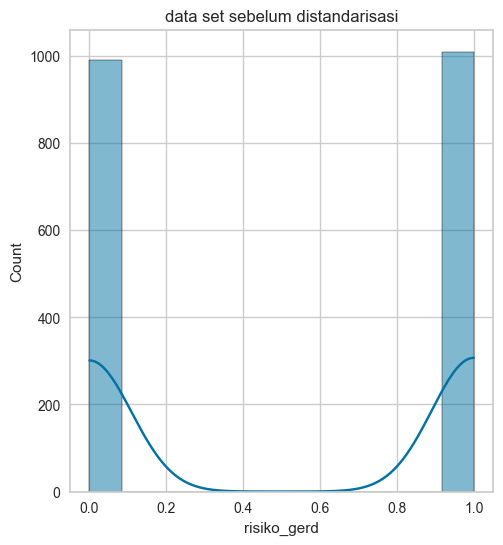

In [18]:
#standarisasi data 

#melihat data sebelum distandarisasi

for i in model_final.columns:
    
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    sns.histplot(model_final[i], kde=True)
    plt.title("data set sebelum distandarisasi")
    plt.show()


In [19]:
#scaling data 

scaler = StandardScaler()
x_latih_stdr = scaler.fit_transform(x_latih_encode)
x_uji_stdr = scaler.transform(x_uji_encode)

print(x_latih_stdr.shape) #melihat jumlah data setelah distandarisasi
print(x_uji_stdr.shape) #melihat jumlah data setelah distandarisasi

(1400, 233)
(600, 233)


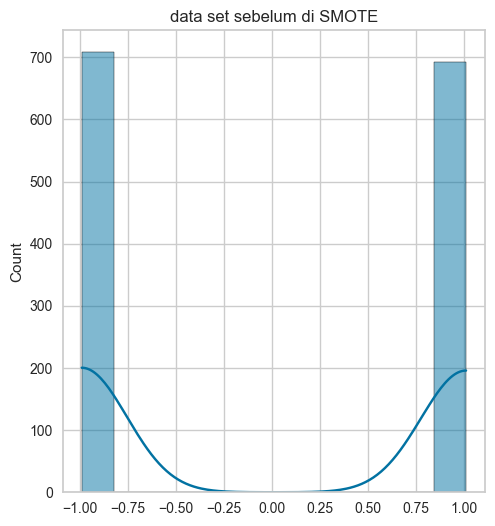

In [20]:
plt.figure(figsize=(12, 6)) 
plt.subplot(1, 2, 1)
sns.histplot(x_latih_stdr[:, 0], kde=True)
plt.title("data set sebelum di SMOTE")
plt.show() 

In [21]:
model_final.head() 

,jenis_kelamin,bmi,status_merokok,tingkat_aktivitas_fisik,jam_tidur_per_malam,tingkat_stres,frekuensi_makan_pedas,frekuensi_makan_berlemak,konsumsi_kopi_per_hari,konsumsi_alkohol,minuman_bersoda_per_minggu,frekuensi_fast_food_per_minggu,makan_larut_malam,risiko_gerd
0,Laki-laki,34.9,Tidak Merokok,Rendah,6,Sedang,Kadang,Kadang,1,Mingguan,5,1,Tidak,0
1,Laki-laki,31.9,Perokok Aktif,Rendah,4,Tinggi,Kadang,Kadang,5,Sesekali,14,5,Ya,1
2,Perempuan,29.8,Perokok Aktif,Tinggi,4,Sedang,Jarang,Sering,1,Mingguan,7,2,Ya,1
3,Perempuan,27.1,Perokok Aktif,Tinggi,4,Tinggi,Jarang,Jarang,2,Tidak Pernah,12,6,Tidak,1
4,Laki-laki,25.6,Tidak Merokok,Sedang,7,Tinggi,Kadang,Sering,0,Tidak Pernah,6,1,Ya,1


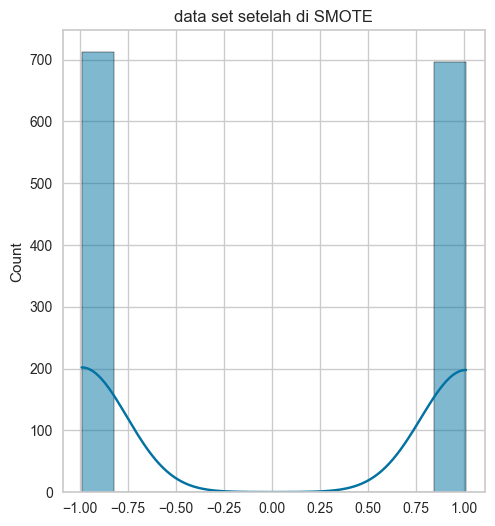

In [22]:
SMOTE_MODEL = SMOTE(random_state=42)
x_latih_smote, y_latih_smote = SMOTE_MODEL.fit_resample(x_latih_stdr, y_latih)

plt.figure(figsize=(12, 6)) 
plt.subplot(1, 2, 1)
sns.histplot(x_latih_smote[:, 0], kde=True)
plt.title("data set setelah di SMOTE")
plt.show() 

In [23]:
#pengeecekan data setelah di SMOTE
print(f"sebelum SMOTE: {y_latih.value_counts()}")
print(f"setelah SMOTE: {y_latih_smote.value_counts()}")
print(f"shape setelah SMOTE: {x_latih_smote.shape}")
print(f"shape setelah standardisasi: {x_latih_stdr.shape}")

sebelum SMOTE: risiko_gerd
1    706
0    694
Name: count, dtype: int64
setelah SMOTE: risiko_gerd
0    706
1    706
Name: count, dtype: int64
shape setelah SMOTE: (1412, 233)
shape setelah standardisasi: (1400, 233)


In [24]:
x = 706 - 694
print(x)

12


In [25]:
print(SMOTE)

<class 'imblearn.over_sampling._smote.base.SMOTE'>


In [26]:
#kali ini kita sudah masuk kebagian modeling, develop model kita setelah melakukan SMOTE
